### [Journal Image Reproduction - Circular Correlation Heatmaps with Grouped Regions](https://medium.com/top-python-libraries/journal-image-reproduction-python-drawing-of-circular-correlation-heatmaps-with-grouped-regions-a3a3c9ebf818)

In [1]:
# =========================================================================================
# ====================================== 1.Import library =========================================
# =========================================================================================
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from scipy import stats

from IPython.display import display
try:
    import google.colab
    IN_COLAB = True
except ImportError:
  if 'COLAB_GPU' in os.environ or 'COLAB_TPU_ADDR' in os.environ:
    IN_COLAB = True
  else:
    IN_COLAB = False

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=4, suppress=True)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
if not IN_COLAB:
  plt.rcParams['font.family'] = 'Times New Roman'

import warnings
warnings.filterwarnings('ignore')

import dotenv
%load_ext dotenv

In [2]:
# =========================================================================================
# ======================================2.Color library settings=========================================
# =========================================================================================
COLOR_THEMES = {
    1: {'group_colors': {'TFs': '#3B5F8A', 'VIs': '#E68B3A', 'DVS': '#707070', 'PI': '#A65E60', 'MC': '#8A6B94'},
        'heatmap_colors': ["#43A8A8", "white", "#D75F5F"]},
    2: {'group_colors': {'TFs': '#2E7D32', 'VIs': '#FF8F00', 'DVS': '#616161', 'PI': '#8D6E63', 'MC': '#6A1B9A'},
        'heatmap_colors': ["#388E3C", "white", "#D32F2F"]},
    3: {'group_colors': {'TFs': '#4A148C', 'VIs': '#AD1457', 'DVS': '#455A64', 'PI': '#C2185B', 'MC': '#004D40'},
        'heatmap_colors': ["#1976D2", "#FFFFFF", "#E91E63"]},
    4: {'group_colors': {'TFs': '#003B46', 'VIs': '#07575B', 'DVS': '#66A5AD', 'PI': '#007580', 'MC': '#0A918C'},
        'heatmap_colors': ["#0D47A1", "#FFFFFF", "#FFC107"]},
    5: {'group_colors': {'TFs': '#6D4C41', 'VIs': '#BF360C', 'DVS': '#795548', 'PI': '#D84315', 'MC': '#4E342E'},
        'heatmap_colors': ["#8D6E63", "#FFF3E0", "#E64A19"]},
    6: {'group_colors': {'TFs': '#42275A', 'VIs': '#734B6D', 'DVS': '#E86A92', 'PI': '#F47983', 'MC': '#6A1B9A'},
        'heatmap_colors': ["#311B92", "#FFECB3", "#E65100"]},
    7: {'group_colors': {'TFs': '#1B5E20', 'VIs': '#2E7D32', 'DVS': '#558B2F', 'PI': '#7CB342', 'MC': '#3E2723'},
        'heatmap_colors': ["#2E7D32", "#F1F8E9", "#BF360C"]},
    8: {'group_colors': {'TFs': '#1C3144', 'VIs': '#30475E', 'DVS': '#7E8A97', 'PI': '#5C6F7F', 'MC': '#046582'},
        'heatmap_colors': ["#263238", "#ECEFF1", "#0277BD"]},
    9: {'group_colors': {'TFs': '#311B92', 'VIs': '#4527A0', 'DVS': '#7B1FA2', 'PI': '#9C27B0', 'MC': '#F9A825'},
        'heatmap_colors': ["#4A148C", "#FFF8E1", "#FFAB00"]},
    10: {'group_colors': {'TFs': '#212121', 'VIs': '#424242', 'DVS': '#757575', 'PI': '#9E9E9E', 'MC': '#616161'},
         'heatmap_colors': ["#000000", "#FFFFFF", "#BDBDBD"]},
    11: {'group_colors': {'TFs': '#A2D0C1', 'VIs': '#E2A0B7', 'DVS': '#F6E5A8', 'PI': '#B1A8D0', 'MC': '#FFB085'},
         'heatmap_colors': ["#81C784", "#FFFFFF", "#CE93D8"]},
    12: {'group_colors': {'TFs': '#440154', 'VIs': '#3B528B', 'DVS': '#21908C', 'PI': '#5DC863', 'MC': '#FDE725'},
         'heatmap_colors': ["#0D0887", "#FFFFFF", "#F0F921"]},
    13: {'group_colors': {'TFs': '#93634B', 'VIs': '#C88C5A', 'DVS': '#E3B27D', 'PI': '#A5492A', 'MC': '#5D3A2D'},
         'heatmap_colors': ["#A1887F", "#FFFFFF", "#42A5F5"]},
    14: {'group_colors': {'TFs': '#009FB7', 'VIs': '#FED766', 'DVS': '#247BA0', 'PI': '#F25F5C', 'MC': '#70C1B3'},
         'heatmap_colors': ["#005969", "#FFFFFF", "#FF427E"]},
    15: {'group_colors': {'TFs': '#588157', 'VIs': '#84A98C', 'DVS': '#A3B18A', 'PI': '#B38A58', 'MC': '#3A5A40'},
         'heatmap_colors': ["#344E41", "#FFFFFF", "#BC6C25"]},
    16: {'group_colors': {'TFs': '#C36B84', 'VIs': '#E69597', 'DVS': '#F5B9B2', 'PI': '#813745', 'MC': '#59292F'},
         'heatmap_colors': ["#880E4F", "#FCE4EC", "#4E342E"]},
    17: {'group_colors': {'TFs': '#0B0C10', 'VIs': '#1F2833', 'DVS': '#45A29E', 'PI': '#66FCF1', 'MC': '#C5C6C7'},
         'heatmap_colors': ["#00003f", "#FFFFFF", "#7A0099"]},
    18: {'group_colors': {'TFs': '#4878CF', 'VIs': '#6ACC65', 'DVS': '#D65F5F', 'PI': '#B47CC7', 'MC': '#DC843D'},
         'heatmap_colors': ["#4C72B0", "#FFFFFF", "#DD8452"]},
    19: {'group_colors': {'TFs': '#F4B71B', 'VIs': '#FA7921', 'DVS': '#E55934', 'PI': '#9BC53D', 'MC': '#5BC0EB'},
         'heatmap_colors': ["#588157", "#FFFFFF", "#F9A620"]},
    20: {'group_colors': {'TFs': '#2D2D2A', 'VIs': '#595954', 'DVS': '#83837E', 'PI': '#B46549', 'MC': '#988880'},
         'heatmap_colors': ["#36454F", "#FFFFFF", "#B87333"]},
    21: {'group_colors': {'TFs': '#1A425D', 'VIs': '#546A7B', 'DVS': '#8C9BAB', 'PI': '#C2CCDA', 'MC': '#2B2D42'},
         'heatmap_colors': 'coolwarm'},
    22: {'group_colors': {'TFs': '#440154', 'VIs': '#31688E', 'DVS': '#21918C', 'PI': '#35B779', 'MC': '#1F4060'},
         'heatmap_colors': 'viridis'},
    23: {'group_colors': {'TFs': '#0D0887', 'VIs': '#5B02A3', 'DVS': '#9B179E', 'PI': '#CC4678', 'MC': '#4B0395'},
         'heatmap_colors': 'plasma'},
    24: {'group_colors': {'TFs': '#000004', 'VIs': '#57106E', 'DVS': '#9C179E', 'PI': '#ED6925', 'MC': '#420A68'},
         'heatmap_colors': 'inferno'},
    25: {'group_colors': {'TFs': '#000004', 'VIs': '#3B0F70', 'DVS': '#8C2981', 'PI': '#DE4968', 'MC': '#6A217C'},
         'heatmap_colors': 'magma'},
    26: {'group_colors': {'TFs': '#00204E', 'VIs': '#00528A', 'DVS': '#4080A5', 'PI': '#7AB0C2', 'MC': '#2F4858'},
         'heatmap_colors': 'cividis'},
    27: {'group_colors': {'TFs': '#053061', 'VIs': '#2166AC', 'DVS': '#92C5DE', 'PI': '#67001F', 'MC': '#4393C3'},
         'heatmap_colors': 'bwr'},
    28: {'group_colors': {'TFs': '#003C30', 'VIs': '#01665E', 'DVS': '#5AB4AC', 'PI': '#8E0152', 'MC': '#35978F'},
         'heatmap_colors': 'seismic'},
    29: {'group_colors': {'TFs': '#B2182B', 'VIs': '#D6604D', 'DVS': '#F4A582', 'PI': '#4393C3', 'MC': '#2166AC'},
         'heatmap_colors': 'RdBu_r'},
    30: {'group_colors': {'TFs': '#00008F', 'VIs': '#0090FF', 'DVS': '#00FFFF', 'PI': '#FFFF00', 'MC': '#FF0000'},
         'heatmap_colors': 'jet'},
    31: {'group_colors': {'TFs': '#23171B', 'VIs': '#4D3C5D', 'DVS': '#6A65A3', 'PI': '#6895D1', 'MC': '#53A196'},
         'heatmap_colors': 'turbo'},
    32: {'group_colors': {'TFs': '#9400D3', 'VIs': '#0000FF', 'DVS': '#00FF00', 'PI': '#FFFF00', 'MC': '#FF0000'},
         'heatmap_colors': 'gist_rainbow'},
    33: {'group_colors': {'TFs': '#00425A', 'VIs': '#1F8A70', 'DVS': '#BFDB38', 'PI': '#FC7300', 'MC': '#005B7F'},
         'heatmap_colors': 'ocean'},
    34: {'group_colors': {'TFs': '#346B31', 'VIs': '#779F63', 'DVS': '#C4D69B', 'PI': '#A49580', 'MC': '#567D46'},
         'heatmap_colors': 'terrain'},
    35: {'group_colors': {'TFs': '#2D274E', 'VIs': '#4A4C7D', 'DVS': '#6A74A8', 'PI': '#8D9DD1', 'MC': '#3A3A69'},
         'heatmap_colors': 'cubehelix'},
    36: {'group_colors': {'TFs': '#000000', 'VIs': '#550000', 'DVS': '#AA0000', 'PI': '#FF5500', 'MC': '#FFAA00'},
         'heatmap_colors': 'gnuplot'},
    37: {'group_colors': {'TFs': '#FADADD', 'VIs': '#F9C4D2', 'DVS': '#F7AEC1', 'PI': '#F38FB8', 'MC': '#E26D9F'},
         'heatmap_colors': 'spring'},
    38: {'group_colors': {'TFs': '#C4DFBC', 'VIs': '#A9D3B2', 'DVS': '#8DC6A9', 'PI': '#65B49F', 'MC': '#4BA296'},
         'heatmap_colors': 'summer'},
    39: {'group_colors': {'TFs': '#4B120B', 'VIs': '#7B1B0B', 'DVS': '#AF2B0B', 'PI': '#E3440B', 'MC': '#63150B'},
         'heatmap_colors': 'autumn'},
    40: {'group_colors': {'TFs': '#0F3C58', 'VIs': '#1E526C', 'DVS': '#316C85', 'PI': '#4989A1', 'MC': '#255E7A'},
         'heatmap_colors': 'winter'}
}

In [3]:
# =========================================================================================
# ======================================3.Plotting function=========================================
# =========================================================================================
def create_correlation_circos(df, df_sig, stages, groups, color_palette):
    # Extract colors for feature groups
    group_colors = color_palette['group_colors']
    # Extract colors for the heatmap values
    heatmap_colors_value = color_palette['heatmap_colors']

    # Initialize figure with polar projection
    fig, ax = plt.subplots(figsize=(16, 14), subplot_kw=dict(projection='polar'))

    # Total number of features (slices)
    N_features = len(df)
    # Define arc length; the '2.5' constant creates a visual gap in the circle
    arc_length = 2 * np.pi * (N_features / (N_features + 2.5))

    single_bar_span = arc_length / N_features  # Angular span per feature
    width = single_bar_span * 0.98            # Bar width with a tiny gap between slices

    start_angle = (np.pi / 2) + (single_bar_span / 2) # Starting angle (12 o'clock position)
    end_angle = start_angle + (N_features - 1) * single_bar_span # Ending angle

    # Generate angular positions for the center of each bar
    theta = np.linspace(start_angle, end_angle, N_features)
    # Generate radii for each concentric layer
    radii = np.arange(5, 5 + len(stages))
    # Radius for the inner category grouping ring
    category_radius = radii[0] - 1

    # Determine if heatmap color config is a Matplotlib preset or custom
    if isinstance(heatmap_colors_value, str):
        cmap = plt.get_cmap(heatmap_colors_value)
    else:
        # Create a custom linear segmented colormap
        colors = heatmap_colors_value
        nodes = [0.0, 0.5, 1.0] # Define positions on the color scale
        cmap = LinearSegmentedColormap.from_list("custom_cmap", list(zip(nodes, colors)))

    # Normalize correlation values (-1 to 1) for color mapping
    norm = plt.Normalize(vmin=-1, vmax=1)

    # Iterate through each target variable (each concentric ring)
    for i, stage in enumerate(stages):
        r = radii[i] # Current ring radius
        values = df[stage] # Correlation values for current target
        cell_colors = cmap(norm(values)) # Map values to colors

        # Draw the bars forming one layer of the heatmap
        ax.bar(theta,
               height=0.9,      # Radial height of the bar
               width=width,     # Angular width
               bottom=r,        # Starting radius
               color=cell_colors,
               edgecolor='white',
               linewidth=0.5)

        # Iterate through values in the current layer to add text annotations
        for j, val in enumerate(values):
            angle = theta[j]
            radius = r + 0.45 # Center position for text in the cell
            # Add an asterisk if the p-value indicates significance
            sig_marker = '*' if df_sig.iloc[j, i] else ''
            text_val = f'{val:.2f}{sig_marker}'

            # Calculate text rotation to be perpendicular to the radial axis
            rot = np.rad2deg(angle)
            rot -= 90

            ax.text(angle,
                    radius,
                    text_val,
                    ha='center',
                    va='center',
                    fontsize=11,
                    rotation=rot,
                    rotation_mode='anchor')

    # Assign colors to features based on their group; default to grey if not found
    category_colors = [next((group_colors[g] for g, m in groups.items() if f in m), '#CCCCCC') for f in df.index]

    # Draw the innermost ring representing feature groups
    ax.bar(theta,
           height=0.9,
           width=width,
           bottom=category_radius,
           color=category_colors,
           edgecolor='white',
           linewidth=0.5)

    # Calculate radius for feature name labels on the outermost circle
    label_radius = radii[-1] + 1.2
    for i, feature_name in enumerate(df.index):
        angle = theta[i]
        rot = np.rad2deg(angle)
        rot -= 90 # Adjust rotation for readability

        ax.text(angle,
                label_radius,
                feature_name,
                ha='center',
                va='center',
                fontsize=12.5,
                rotation=rot,
                rotation_mode='anchor')

    # Create the legend for feature groups
    legend_elements = [Patch(facecolor=color, edgecolor='black', linewidth=0.5, label=name)
                       for name, color in group_colors.items()]

    # Place legend in the center of the rings
    ax.legend(handles=legend_elements,
              loc='center',
              frameon=False,
              fontsize=12,
              title='Feature Types',
              labelspacing=0.8,
              title_fontproperties={'weight': 'bold', 'size': 14})

    # Visual cleanup: remove default polar grids and spines
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_xticklabels([])

    # Set radial limits and define the "North" angle for labels
    ax.set_ylim(0, label_radius + 1)
    north_angle = np.pi / 2

    # Add target variable labels (stages) at the 12 o'clock position
    label_radii = radii + 0.45
    for i, label in enumerate(stages):
        ax.text(north_angle,
                label_radii[i],
                f' {label}',
                ha='left',
                va='center',
                fontsize=12,
                rotation=0)

    # Add significance key
    ax.text(north_angle,
            radii[0] - 0.55,
            ' * p < 0.05',
            ha='left',
            va='center',
            fontsize=12,
            rotation=0)

    # Add a separate axes for the colorbar
    cax = fig.add_axes([0.85, 0.2, 0.01, 0.6])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(f'{correlation_method.capitalize()} coefficient', size=12, labelpad=10)

    # Save output to PNG and PDF
    if not IN_COLAB:
      png_filename = f"{selected_scheme}.png"
      pdf_filename = f"{selected_scheme}.pdf"
      plt.savefig(png_filename, format='png', dpi=300, bbox_inches='tight')
      plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    else:
      plt.tight_layout()
      plt.show()
    plt.close(fig)

Correlation Analysis Results:


,Vegetative Stage,Flowering Stage,Grain Filling Stage,All
Plant height,0.0577,0.0110,-0.0033,0.0049
band 5 contrast,-0.0416,-0.0339,-0.0477,-0.0108
band 5 mean,-0.0292,-0.0414,0.0245,0.0080
band 1 variance,-0.0205,-0.0594,0.0202,0.0564
band 2 contrast,-0.0203,-0.0204,-0.0592,0.0146
band 5 dissimilarity,0.0094,0.0493,0.0841,-0.0590
band 4 contrast,-0.0361,0.0454,0.0163,-0.0794
band 5 variance,-0.0424,0.0162,-0.0210,-0.0532
band 3 variance,-0.0471,-0.0336,0.0032,-0.0145
SIPI,-0.0223,-0.0065,0.0238,0.0485


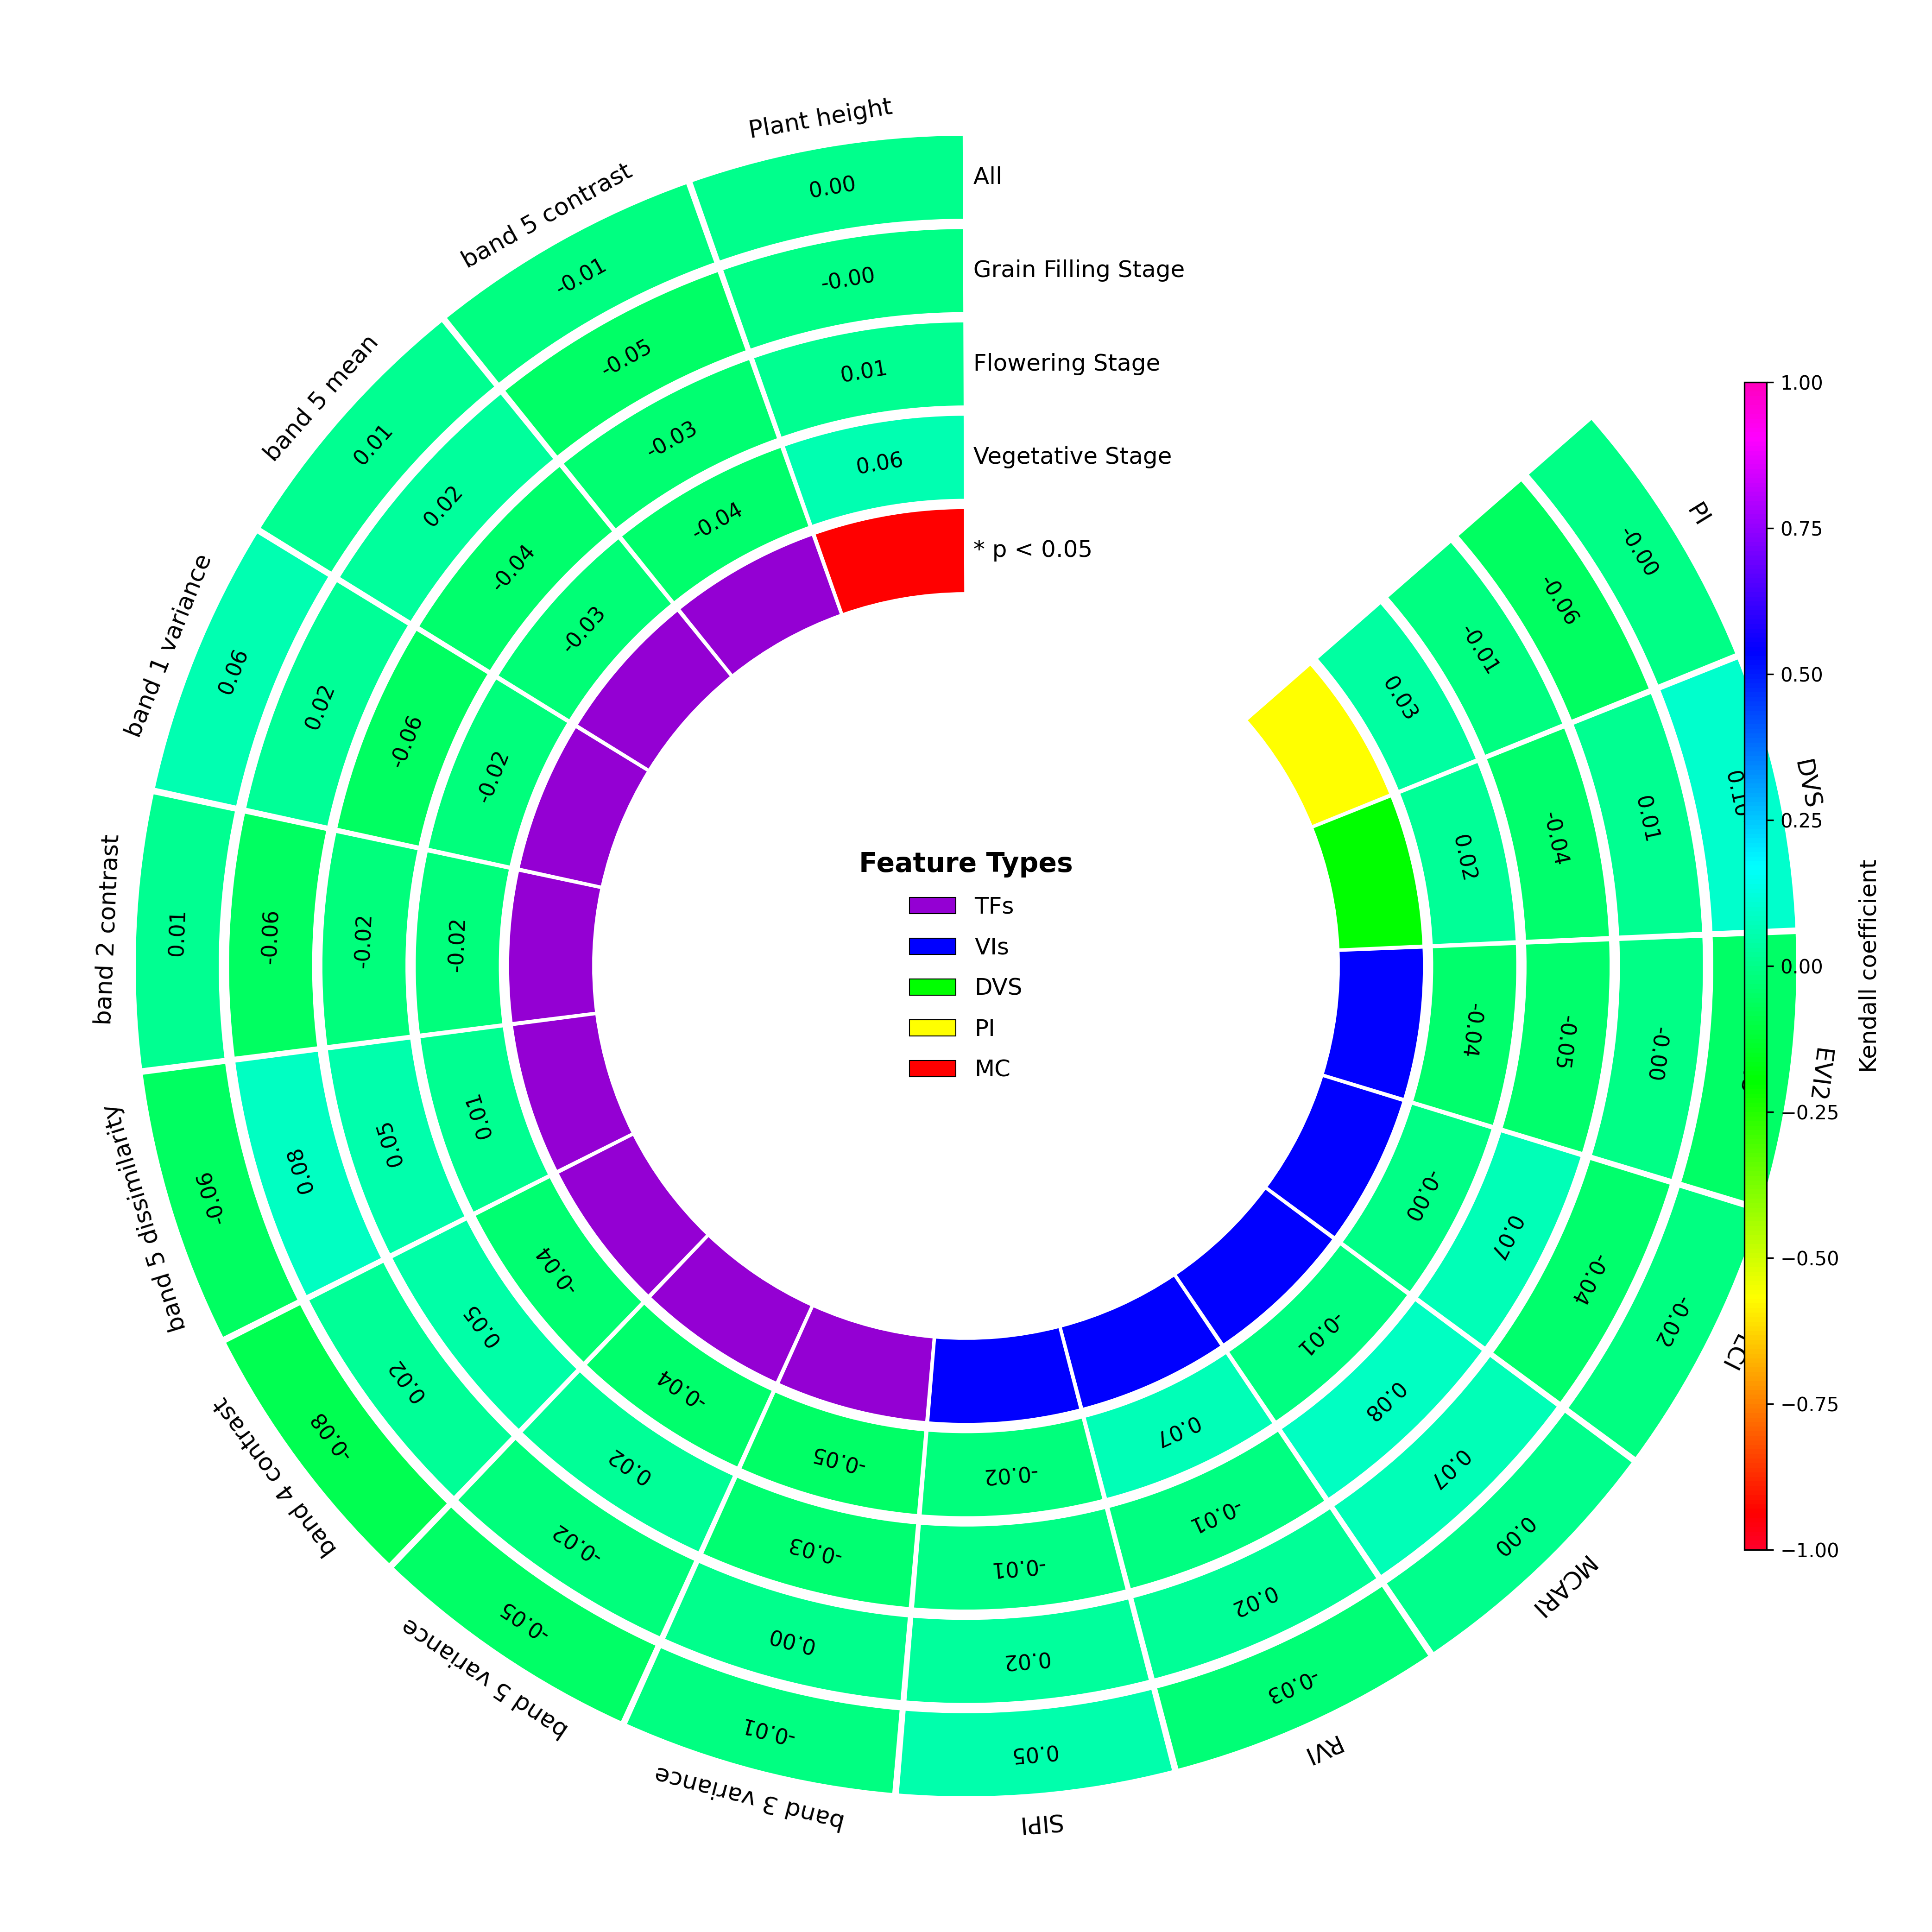

In [4]:
# =========================================================================================
# ======================== 4. Preparation Before Analysis & Plotting ======================
# =========================================================================================
if __name__ == "__main__":
    # Path to the raw data source
    excel_file_path = r"https://github.com/checkming00/Medium_datasets/raw/refs/heads/main/Circular%20Correlation%20Heatmaps%20with%20Grouped%C2%A0Regions/simulated_single_dataset.xlsx"

    # Choose the correlation analysis method: 'pearson', 'spearman', or 'kendall'
    correlation_method = 'kendall'

    # Selection of the color palette ID
    selected_scheme = 32

    # Extract the chosen color scheme from the predefined COLOR_THEMES library
    select_color = COLOR_THEMES.get(selected_scheme, 1)

    # Load the dataset into a pandas DataFrame
    all_data = pd.read_excel(excel_file_path)

    # Extract feature variable names (the first 16 columns) and convert to a list
    final_features = all_data.columns[0:16].tolist()

    # Extract target variable names (from column 16 onwards) and convert to a list
    targets = all_data.columns[16:].tolist()

    # Organize feature variables into functional groups for categorical coloring
    groups = {
        'MC': ['Plant height'],
        'TFs': [
            'band 5 contrast', 'band 5 mean', 'band 1 variance',
            'band 2 contrast', 'band 5 dissimilarity',
            'band 4 contrast', 'band 5 variance', 'band 3 variance'
        ],
        'VIs': ['SIPI', 'RVI', 'MCARI', 'LCI', 'EVI2'],
        'DVS': ['DVS'],
        'PI': ['PI']
    }

    # =========================================================================================
    # ============================== 5. Correlation Analysis ==================================
    # =========================================================================================

    # Dictionary to store correlation coefficients for each feature against all targets
    feature_map_visual = {}
    # Dictionary to store whether the p-value for each correlation is significant
    sig_map_visual = {}

    # Iterate through features to calculate correlation between each feature and all targets
    for feature in final_features:
        # Temporary list to store correlation coefficients for the current feature
        corr_row = []
        # Temporary list to store significance test results (Boolean) for the current feature
        sig_row = []

        # Perform correlation analysis based on the selected method
        for target in targets:
            if correlation_method == 'pearson':
                # Measures linear relationship
                corr, p_value = stats.pearsonr(all_data[feature].dropna(), all_data[target].dropna())
            elif correlation_method == 'spearman':
                # Measures monotonic relationship (rank-based)
                corr, p_value = stats.spearmanr(all_data[feature].dropna(), all_data[target].dropna())
            elif correlation_method == 'kendall':
                # Measures ordinal association
                corr, p_value = stats.kendalltau(all_data[feature].dropna(), all_data[target].dropna())
            else:
                raise ValueError("Please select 'pearson', 'spearman', or 'kendall'")

            # Append the correlation coefficient result
            corr_row.append(corr)
            # Check if significance meets the threshold (p < 0.05) and append
            sig_row.append(p_value < 0.05)

        # Store the list of correlation coefficients for the current feature in the dictionary
        feature_map_visual[feature] = corr_row
        # Store the list of significance results for the current feature in the dictionary
        sig_map_visual[feature] = sig_row

    # Create a DataFrame where rows are features and columns are targets
    # Transpose (.T) and reindex to ensure the order matches the original feature list
    df = pd.DataFrame(feature_map_visual, index=targets).T.reindex(final_features)
    print("Correlation Analysis Results:")
    display(df)

    # Perform the same operations for the significance dictionary to create a corresponding DataFrame
    df_sig = pd.DataFrame(sig_map_visual, index=targets).T.reindex(final_features)

    # Call the previously defined plotting function and pass all necessary parameters
    create_correlation_circos(
        df=df,                  # Correlation coefficient values
        df_sig=df_sig,          # Significance (p-values < 0.05)
        stages=targets,         # The number of targets determines the number of concentric rings
        groups=groups,          # Feature grouping information for the inner ring
        color_palette=select_color  # Selected color scheme
    )